# Getting started with Google ADK in Colab

This notebook is a hands-on introduction to the [Agent Development Kit (ADK)](https://adk.dev) - Google's open-source framework for building AI agents.

We'll go from zero to a working multi-agent system, step by step:

- **Part 1** - Simplest possible agent (just an LLM wrapped in ADK's Agent/Runner/Session structure)
- **Part 2** - Adding tools (custom Python functions the agent can call), including **Exercise**
- **Part 3** - Multi-agent delegation (a root agent that routes queries to specialized sub-agents)
- **Exercise** - Build your own multi-agent system from scratch (ML experiment tracker)

Each part builds on the previous one. By the end you'll understand the core ADK building blocks: `Agent`, `Runner`, `InMemorySessionService`, tools, sub-agents, and how delegation works.

### Prerequisites
- A Gemini API key from [Google AI Studio](https://aistudio.google.com/apikey) (free tier works fine)
- Basic Python knowledge
- That's it - everything else runs in this notebook

### Resources
- [ADK documentation](https://adk.dev)
- [ADK Python repo](https://github.com/google/adk-python)
- [ADK samples](https://github.com/google/adk-samples)


In [ ]:
# @title Install `google-adk` package
%pip install -q google-adk

In [ ]:
import IPython
# restart Kernel after google-adk installation
IPython.Application.instance().kernel.do_shutdown(restart=True)

In [ ]:
import os
os.environ["GOOGLE_GENAI_USE_VERTEXAI"] = "True"
os.environ["GOOGLE_CLOUD_PROJECT"] = "tomek-experiments"  # Update project ID
os.environ["GOOGLE_CLOUD_LOCATION"] = "europe-west1"  # Potentially update the region

### How ADK runs in a notebook

When you use `adk web` or `adk run` from the command line, ADK spins up a server that handles everything for you behind a web UI or terminal prompt.

In a notebook, there's no server. Instead, you wire up three components manually:

- **Agent** - the LLM brain (model, instructions, tools)
- **Runner** - the engine that orchestrates the conversation loop
- **SessionService** - stores conversation history across turns

When you call `runner.run_async()` with a message, the Runner sends it to the Gemini API, handles any tool calls locally in your Python process, saves everything to the session, and returns the response. That's the entire loop - no background processes, no servers.

This is more code than `adk web`, but it gives you full control and visibility into what's happening - which is exactly what you want when learning.

In [ ]:
# @title Imports and define `call_agent` function

import contextlib
from google.adk.runners import Runner
from google.adk.sessions import InMemorySessionService
from google.genai import types

import warnings
warnings.filterwarnings("ignore")

async def call_agent(query: str, runner: Runner, user_id: str, session_id: str):
    """Sends a query to the agent and prints the final response."""
    print(f"\n>>> User: {query}")

    content = types.Content(role="user", parts=[types.Part(text=query)])

    final_response = "Agent did not produce a final response."

    async with contextlib.aclosing(runner.run_async(
        user_id=user_id, session_id=session_id, new_message=content
    )) as stream:
        async for event in stream:
            # this is only for 'workshop' to increase vistibility
            if event.author and event.content and event.content.parts:
                if event.author and event.content and event.content.parts:
                    part = event.content.parts[0]
                    if part.function_call:
                        print(f"  [{event.author}]: (tool call: {part.function_call.name})...")
                    elif part.text:
                        print(f"  [{event.author}]: {part.text[:80]}...")
            if event.is_final_response():
                if event.content and event.content.parts:
                    final_response = event.content.parts[0].text
                elif event.actions and event.actions.escalate:
                    final_response = f"Agent escalated: {event.error_message or 'No details.'}"
                break

    print(f"<<< Agent: {final_response}")

### Part 1: Simplest agent - just an LLM

In this part we create the simplest possible ADK agent - no tools, no sub-agents, just an LLM that can chat. You could do this with a raw `generateContent` call, so why bother with ADK?

Because ADK gives you three building blocks that matter once things get more complex:

- **Agent** - defines the LLM model, instructions, and (later) tools and sub-agents
- **Runner** - the engine that sends messages to the agent, handles tool calls, and manages the conversation loop
- **InMemorySessionService** - stores conversation history so the agent remembers previous turns within a session

We set all three up now, even though it feels like overkill for a simple chatbot. The payoff comes in Parts 2 and 3 when we add tools and multi-agent delegation - the structure stays exactly the same, we just plug in more pieces.

In [ ]:
from google.adk.agents import Agent

simple_agent = Agent(
    name="simple_agent",
    model="gemini-2.5-flash",
    description="A simple conversational assistant.",
    instruction="You are a friendly and helpful assistant. Answer the user's questions concisely.",
)

print(f"Agent created: {simple_agent.name}")

Let's create a runner and session for our agent

In [ ]:
APP_NAME = "quickstart_app"
USER_ID = "user_1"
SESSION_ID = "session_001"

session_service = InMemorySessionService()

runner = Runner(
    agent=simple_agent,
    app_name=APP_NAME,
    session_service=session_service,
)

session = await session_service.create_session(
    app_name=APP_NAME, user_id=USER_ID, session_id=SESSION_ID
)

print(f"Session created: {session.id}")

In [ ]:
await call_agent("Hello! What can you do?", runner=runner, user_id=USER_ID, session_id=SESSION_ID)

In [ ]:
await call_agent("My name is Tomek, what's yours?", runner=runner, user_id=USER_ID, session_id=SESSION_ID)

In [ ]:
await call_agent("can you recall my name?", runner=runner, user_id=USER_ID, session_id=SESSION_ID)

### Part 2: Agent with tools

Tools can be Python functions that give the agent abilities the LLM doesn't have on its own - calling APIs, querying databases, running calculations, checking the time.

In ADK, any Python function can become a tool. The only requirement: **the docstring matters**. The LLM reads it to decide *when* to call the tool, *what arguments* to pass, and *what to expect back*. A vague or missing docstring means the agent won't use the tool correctly.

We'll define two mock tools (`get_weather` and `get_current_time`), attach them to an agent, and let the LLM decide which one to call based on the user's query.

In [ ]:
await call_agent("Who is the current prime minister of the United Kingdom?", runner=runner, user_id=USER_ID, session_id=SESSION_ID)

#### Built-in tools

Before we write custom tools, let's see a built-in one. ADK ships with tools like `google_search` that you can plug into any agent.

Watch what happens when we ask the same question to an agent without tools (relying on training data) vs one with Google Search:

In [ ]:
from google.adk.tools import google_search

search_agent = Agent(
    name="search_agent",
    model="gemini-2.5-flash",
    description="An agent that can search the web for current information.",
    instruction="You are a helpful assistant. Use Google Search to find current, accurate information.",
    tools=[google_search],
)

async def setup_search_agent():
    search_session_service = InMemorySessionService()
    session = await search_session_service.create_session(
        app_name="search_app", user_id=USER_ID, session_id="search_session_001"
    )
    return Runner(
        agent=search_agent,
        app_name="search_app",
        session_service=search_session_service,
    )

search_runner = await setup_search_agent()


In [ ]:
await call_agent("Who is the current prime minister of the United Kingdom?", runner=search_runner, user_id=USER_ID, session_id="search_session_001")

In [ ]:
# Query the search agent and show grounding sources
content = types.Content(role="user", parts=[types.Part(text="Who is the current prime minister of the United Kingdom?")])

async with contextlib.aclosing(search_runner.run_async(
    user_id=USER_ID, session_id="search_session_001", new_message=content
)) as stream:
    async for event in stream:
        if event.is_final_response():
            if event.content and event.content.parts:
                print(f"Agent: {event.content.parts[0].text}\n")

            if hasattr(event, "grounding_metadata") and event.grounding_metadata:
                gm = event.grounding_metadata
                if gm.grounding_chunks:
                    print("Sources:")
                    for chunk in gm.grounding_chunks:
                        print(f"  - {chunk.web.title}: {chunk.web.uri}")
                if gm.web_search_queries:
                    print(f"\nSearch queries used: {gm.web_search_queries}")
            else:
                print("(No grounding metadata returned)")
            break

# Custom tools

Let's define two functions - one to get the weather, current location (both using mock data) and another to get the current time. We'll later pass these as custom tools to our Agent. Note the detailed descriptions in docstrings - the LLM relies on them to understand what each tool does and when to call it.

In [ ]:
import datetime
from zoneinfo import ZoneInfo


def get_weather(city: str) -> dict:
    """Retrieves the current weather report for a specified city.

    Args:
        city (str): The name of the city for which to retrieve the weather report.

    Returns:
        dict: A dictionary containing the weather information.
              Includes a 'status' key ('success' or 'error').
              If 'success', includes a 'report' key with weather details.
              If 'error', includes an 'error_message' key.
    """
    print(f"--- Tool: get_weather called for city: {city} ---")
    mock_weather = {
        "new york": "Sunny, 25°C (77°F)",
        "london": "Cloudy, 15°C (59°F)",
        "tokyo": "Rainy, 20°C (68°F)",
    }
    weather = mock_weather.get(city.lower())
    if weather:
        return {"status": "success", "report": f"Weather in {city}: {weather}"}
    return {"status": "error", "error_message": f"Weather data for '{city}' not available."}


def get_current_time(city: str) -> dict:
    """Returns the current time in a specified city.

    Args:
        city (str): The name of the city for which to retrieve the current time.

    Returns:
        dict: A dictionary containing the time information.
              Includes a 'status' key ('success' or 'error').
              If 'success', includes a 'report' key with the current time.
              If 'error', includes an 'error_message' key.
    """
    print(f"--- Tool: get_current_time called for city: {city} ---")
    city_timezones = {
        "new york": "America/New_York",
        "london": "Europe/London",
        "tokyo": "Asia/Tokyo",
        "warsaw": "Europe/Warsaw",
    }
    tz_name = city_timezones.get(city.lower())
    if not tz_name:
        return {"status": "error", "error_message": f"Timezone for '{city}' not available."}

    now = datetime.datetime.now(ZoneInfo(tz_name))
    return {
        "status": "success",
        "report": f"Current time in {city}: {now.strftime('%Y-%m-%d %H:%M:%S %Z')}",
    }

def get_my_location() -> dict:
    """Returns the current location of the user.

    Returns:
        dict: A dictionary containing the location information.
              Includes a 'status' key ('success') and a 'location' key with the city name.
    """
    print("--- Tool: get_my_location called ---")
    return {"status": "success", "location": "London"}


print("Tools defined: get_weather, get_current_time, get_my_location")

Now, let's create the tool-equipped agent

In [ ]:
weather_time_agent = Agent(
    name="weather_time_agent",
    model="gemini-2.5-flash",
    description="Agent to answer questions about the time and weather in a city.",
    instruction=(
        "You are a helpful agent who can answer user questions about the time "
        "and weather in a city. Use the available tools to get the information. "
        "If a tool returns an error, inform the user politely."
    ),
    tools=[get_weather, get_current_time, get_my_location],
)

# New session service, runner, and session for the tool agent
tool_session_service = InMemorySessionService()
TOOL_APP_NAME = "tool_app"
TOOL_SESSION_ID = "tool_session_001"

tool_runner = Runner(
    agent=weather_time_agent,
    app_name=TOOL_APP_NAME,
    session_service=tool_session_service,
)

tool_session = await tool_session_service.create_session(
    app_name=TOOL_APP_NAME, user_id=USER_ID, session_id=TOOL_SESSION_ID
)

print(f"Tool agent ready: {weather_time_agent.name}, session: {tool_session.id}")

In [ ]:
await call_agent("What's the weather in New York?", runner=tool_runner, user_id=USER_ID, session_id=TOOL_SESSION_ID)

In [ ]:
# this should call two tools: check my location, and then confirm the weather
await call_agent("What's the weather at my location?", runner=tool_runner, user_id=USER_ID, session_id=TOOL_SESSION_ID)

# Task: update get_weather()

update get_weather() function to get the proper weather forecast, not a mocked one.

Below you have a partially created get_weather() function. your task is to update it, based on exercies we did during Github Copilot labs


In [ ]:
def get_weather(city: str) -> dict:
    """Retrieves the current weather report for a specified city.

    Args:
        city (str): The name of the city for which to retrieve the weather report.

    Returns:
        dict: A dictionary containing the weather information.
              Includes a 'status' key ('success' or 'error').
              If 'success', includes a 'report' key with weather details.
              If 'error', includes an 'error_message' key.
    """
    # update this function


    weather = False
    if weather:
        return {"status": "success", "report": f"Weather in {city}: {weather}"}
    return {"status": "error", "error_message": f"Weather data for '{city}' not available."}

In [ ]:
# Initilize the agent with updated tool

weather_time_agent = Agent(
    name="weather_time_agent",
    model="gemini-2.5-flash",
    description="Agent to answer questions about the time and weather in a city.",
    instruction=(
        "You are a helpful agent who can answer user questions about the time "
        "and weather in a city. Use the available tools to get the information. "
        "If a tool returns an error, inform the user politely."
    ),
    tools=[get_weather, get_current_time],
)

# New session service, runner, and session for the tool agent
tool_session_service = InMemorySessionService()
TOOL_APP_NAME = "tool_app"
TOOL_SESSION_ID = "tool_session_001"

tool_runner = Runner(
    agent=weather_time_agent,
    app_name=TOOL_APP_NAME,
    session_service=tool_session_service,
)

tool_session = await tool_session_service.create_session(
    app_name=TOOL_APP_NAME, user_id=USER_ID, session_id=TOOL_SESSION_ID
)

print(f"Tool agent ready: {weather_time_agent.name}, session: {tool_session.id}")

## Time to test your solution

In [ ]:
await call_agent("What's the weather in London?", runner=tool_runner, user_id=USER_ID, session_id=TOOL_SESSION_ID)

# Multi-agent

Let's define tools first

In [ ]:
import random
import string
from typing import Optional


def _generate_id(prefix: str = "ID", length: int = 6) -> str:
    """Helper: generates a short random ID like 'USR-A3F8K1'."""
    chars = string.ascii_uppercase + string.digits
    return f"{prefix}-{''.join(random.choices(chars, k=length))}"


def say_hello(name: Optional[str] = None) -> str:
    """Looks up the user in the database and returns a personalized greeting.

    Args:
        name (str, optional): The name of the person to greet.

    Returns:
        str: A personalized greeting with user info.
    """
    print(f"--- Tool: say_hello called (name={name}) ---")

    # Mock database lookup
    known_users = {
        "tomek": "Cloud Engineering",
        "alice": "Marketing",
        "bob": "Finance",
    }

    user_id = _generate_id("USR")

    if name:
        department = known_users.get(name.lower(), "Unknown")
        print(f"--- Tool: User found - ID: {user_id}, Department: {department} ---")
        return f"Hello, {name}! (User ID: {user_id}, Department: {department}) Welcome back!"
    else:
        print(f"--- Tool: Guest user - ID: {user_id} ---")
        return f"Hello there! (Guest ID: {user_id}) Welcome!"


def say_goodbye() -> str:
    """Saves the session to the database and returns a farewell with a reference ID.

    Returns:
        str: A goodbye message with a session reference ID.
    """
    print(f"--- Tool: say_goodbye called ---")

    session_ref = _generate_id("SES")
    print(f"--- Tool: Session saved with ref: {session_ref} ---")
    return f"Goodbye! Your session has been saved. Reference ID: {session_ref}. Have a great day!"


print("Tools defined: say_hello, say_goodbye")

In [ ]:
# Now let's define sub-agents

greeting_agent = Agent(
    name="greeting_agent",
    model="gemini-2.5-flash",
    description="Handles simple greetings and hellos using the 'say_hello' tool.",
    instruction=(
        "You are the Greeting Agent. Your ONLY task is to provide a friendly greeting "
        "using the 'say_hello' tool. If the user provides their name, pass it to the tool. "
        "Do not engage in any other conversation or tasks."
    ),
    tools=[say_hello],
)

farewell_agent = Agent(
    name="farewell_agent",
    model="gemini-2.5-flash",
    description="Handles farewells and goodbyes using the 'say_goodbye' tool.",
    instruction=(
        "You are the Farewell Agent. Your ONLY task is to provide a polite goodbye "
        "using the 'say_goodbye' tool when the user says bye, goodbye, see you, etc. "
        "Do not perform any other actions."
    ),
    tools=[say_goodbye],
)

print(f"Sub-agents created: {greeting_agent.name}, {farewell_agent.name}")

### Define root agent with sub-agents

In [ ]:
# Reset parent references (needed when re-running cells in notebooks)
for agent in [greeting_agent, farewell_agent, weather_time_agent]:
    agent.parent_agent = None

root_agent = Agent(
    name="root_agent",
    model="gemini-2.5-flash",
    description="The main coordinator. Routes to specialists for greetings, farewells, and weather/time.",
    instruction=(
        "You are the main coordinating agent. Analyze each user query and delegate:\n"
        "- Simple greetings (hi, hello, hey) → delegate to 'greeting_agent'\n"
        "- Farewells (bye, goodbye, see you) → delegate to 'farewell_agent'\n"
        "- Weather or time questions → delegate to 'weather_time_agent'\n"
        "- answer user queries about current chat history"
        "- For anything else, respond briefly that you can help with weather, time."
    ),
    tools=[],  # Root agent has no tools of its own - it delegates
    sub_agents=[greeting_agent, farewell_agent, weather_time_agent],
)

print(f"Root agent '{root_agent.name}' created with sub-agents: {[a.name for a in root_agent.sub_agents]}")

In [ ]:
# Setup runner and session for the multi-agent team

MULTI_APP = "multi_agent_app"
MULTI_USER = "user_1"
MULTI_SESSION = "multi_session_001"

async def setup_multi_agent():
    multi_session_service = InMemorySessionService()

    session = await multi_session_service.create_session(
        app_name=MULTI_APP, user_id=MULTI_USER, session_id=MULTI_SESSION
    )

    multi_runner = Runner(
        agent=root_agent,
        app_name=MULTI_APP,
        session_service=multi_session_service,
    )

    print(f"Multi-agent runner ready, session: {session.id}")
    return multi_runner

multi_runner = await setup_multi_agent()

In [ ]:
# Test - greeting (should delegate to greeting_agent)

await call_agent("Hey there! I'm Tomek.", runner=multi_runner, user_id=MULTI_USER, session_id=MULTI_SESSION)

In [ ]:
await call_agent("what's my user id and name based on the history of our conversation?", runner=multi_runner, user_id=MULTI_USER, session_id=MULTI_SESSION)

In [ ]:
await call_agent("what's the weather in Paris?", runner=multi_runner, user_id=MULTI_USER, session_id=MULTI_SESSION)

In [ ]:
await call_agent("ok, thanks for today, goodbye!", runner=multi_runner, user_id=MULTI_USER, session_id=MULTI_SESSION)

---
## Exercise: Build an ML experiment tracker agent team

You've seen how multi-agent delegation works - a root agent analyzes user queries and routes them to specialized sub-agents based on their `description`.

Now it's your turn. You'll build an **ML experiment tracker** - a chat interface that lets data scientists query experiment results, compare runs, and deploy models to staging.

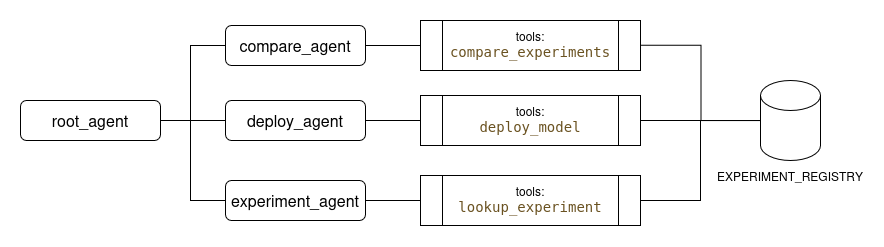

### What you're given
- **Three tools** (next cell): `lookup_experiment`, `compare_experiments`, and `deploy_model`. These are mock implementations - they simulate looking up an experiment registry, comparing two runs, and promoting a model. Run the cell and test them to understand what they return.  **Note: some tools need a bit of an update first!**
- **One completed sub-agent** (`experiment_agent`) as a reference for the pattern.
- **Test queries** to validate your solution.

### What you need to build
1. **Two sub-agents**: `compare_agent` and `deploy_agent` - each wrapping one of the remaining tools. Pay attention to your `description` (this is what the root agent reads to decide where to route) and `instruction` (this tells the agent how to behave and use its tool).
2. **A root agent** that delegates to all three sub-agents. Its `instruction` should clearly describe when to route where.
3. **A runner and session** to test everything (you've done this twice already).

### What "done" looks like
Run the test queries at the end. You should see:
- Experiment lookups routed to `experiment_agent`
- Comparisons routed to `compare_agent`
- Deployments routed to `deploy_agent`
- The `--- Tool: ... called ---` logs confirming the right tool was triggered each time

### Tip
If delegation isn't working correctly, the issue is almost always in the `description` or `instruction` text. The LLM uses these to decide routing - vague descriptions lead to wrong routing.

In [ ]:
# ============================================================
# Mock experiment registry - pretend this is your MLflow / Vertex AI Experiments database
# ============================================================

EXPERIMENT_REGISTRY = {
    "EXP-042": {
        "model": "XGBoost",
        "dataset": "customer_churn_v3",
        "accuracy": 0.91,
        "f1_score": 0.87,
        "params": {"n_estimators": 200, "max_depth": 6, "learning_rate": 0.1},
        "status": "completed",
    },
    "EXP-017": {
        "model": "RandomForest",
        "dataset": "customer_churn_v3",
        "accuracy": 0.88,
        "f1_score": 0.83,
        "params": {"n_estimators": 150, "max_depth": 10, "min_samples_split": 5},
        "status": "completed",
    },
    "EXP-063": {
        "model": "DecisionTree",
        "dataset": "customer_churn_v3",
        "accuracy": 0.82,
        "f1_score": 0.78,
        "params": {"max_depth": 8, "min_samples_leaf": 10},
        "status": "completed",
    },
}


# ============================================================
# REFERENCE TOOL (complete) - use this as a pattern for the other two
# ============================================================

def lookup_experiment(experiment_id: str) -> dict:
    """Looks up an ML experiment by its ID and returns the full result record.

    Args:
        experiment_id (str): The experiment ID to look up (e.g. 'EXP-042').

    Returns:
        dict: The experiment record with model, dataset, metrics, and params,
              or an error message if the experiment is not found.
    """
    print(f"--- Tool: lookup_experiment called for '{experiment_id}' ---")

    experiment = EXPERIMENT_REGISTRY.get(experiment_id.upper())
    if experiment:
        return {"status": "success", "experiment_id": experiment_id, **experiment}
    return {"status": "error", "error_message": f"Experiment '{experiment_id}' not found."}


In [ ]:
# ============================================================
# TODO: Complete the two tools below following the pattern above
# ============================================================

def compare_experiments(experiment_id_1: str, experiment_id_2: str) -> dict:
    """TODO: Write a docstring. The LLM needs it to understand when and how to use this tool.

    Hint: This tool compares two experiments side by side.
    """
    print(f"--- Tool: compare_experiments called for '{experiment_id_1}' vs '{experiment_id_2}' ---")

    # TODO: Look up both experiments from EXPERIMENT_REGISTRY
    # TODO: If both found, return a dict with both results for comparison
    # TODO: If either is missing, return an error message
    pass


def deploy_model(experiment_id: str) -> dict:
    """TODO: Write a docstring. The LLM needs it to understand when and how to use this tool.

    Hint: This tool deploys/promotes a model from a completed experiment to staging.
    """
    print(f"--- Tool: deploy_model called for '{experiment_id}' ---")

    # TODO: Look up the experiment from EXPERIMENT_REGISTRY
    # TODO: If found, generate a mock endpoint URL and return a success confirmation
    #       (you can use _generate_id("END") for the endpoint ID)
    # TODO: If not found, return an error message
    pass

In [ ]:
# ============================================================
# REFERENCE SUB-AGENT (complete) - use this as a pattern for the other two
# ============================================================

experiment_agent = Agent(
    name="experiment_agent",
    model="gemini-2.5-flash",
    description="Looks up ML experiment results by experiment ID from the registry.",
    instruction=(
        "You are the Experiment Lookup Agent. When a user asks about a specific experiment, "
        "use the 'lookup_experiment' tool with the experiment ID they provide. "
        "Present the results clearly: model type, dataset, accuracy, F1 score, and parameters. "
        "If the experiment is not found, let the user know politely."
    ),
    tools=[lookup_experiment],
)

print(f"Reference agent created: {experiment_agent.name}")

In [ ]:
# ============================================================
# TODO: Create compare_agent
# ============================================================
# Hint: Think about what description the root agent needs to see
# to know when to route comparison requests here.

# compare_agent = Agent(
#     ...
# )


# ============================================================
# TODO: Create deploy_agent
# ============================================================
# Hint: What words will users say when they want to deploy?
# Your description should help the root agent recognise those requests.

# deploy_agent = Agent(
#     ...
# )



In [ ]:
# Hint: This resets parent references if you're re-running this cell, no need to change it:
for name in ["experiment_agent", "compare_agent", "deploy_agent"]:
    agent = globals().get(name)
    if agent:
        agent.parent_agent = None

# ============================================================
# TODO: Create the root agent that delegates to all three sub-agents
# ============================================================

# for agent in [experiment_agent, compare_agent, deploy_agent]:
#     agent.parent_agent = None

# root_agent = Agent(
#     ...
# )


# Uncomment to verify:
# print(f"Root agent '{root_agent.name}' with sub-agents: {[a.name for a in root_agent.sub_agents]}")

In [ ]:
# Setup runner and session

EX_APP = "experiment_tracker_app"
EX_USER = "data_scientist_1"
EX_SESSION = "ex_session_001"

async def setup_experiment_tracker():
    ex_session_service = InMemorySessionService()

    session = await ex_session_service.create_session(
        app_name=EX_APP, user_id=EX_USER, session_id=EX_SESSION
    )

    ex_runner = Runner(
        agent=root_agent,
        app_name=EX_APP,
        session_service=ex_session_service,
    )

    print(f"Experiment tracker ready, session: {session.id}")
    return ex_runner

ex_runner = await setup_experiment_tracker()

# Test queries

In [ ]:
# 1. Lookup - should route to experiment_agent
await call_agent("Show me the results of experiment EXP-042", runner=ex_runner, user_id=EX_USER, session_id=EX_SESSION)

In [ ]:
# 2. Comparison - should route to compare_agent
await call_agent("Compare EXP-042 with EXP-017", runner=ex_runner, user_id=EX_USER, session_id=EX_SESSION)

In [ ]:
# 3. Deployment - should route to deploy_agent
await call_agent("Deploy EXP-042 to staging", runner=ex_runner, user_id=EX_USER, session_id=EX_SESSION)

In [ ]:
# 4. Unknown experiment - should handle gracefully
await call_agent("What were the results of EXP-999?", runner=ex_runner, user_id=EX_USER, session_id=EX_SESSION)

In [ ]:
# 5. Ambiguous query - interesting to see where it routes
await call_agent("Which experiment has the best accuracy?", runner=ex_runner, user_id=EX_USER, session_id=EX_SESSION)